# KOA — Vision Transformer (ViT-B/16) — Giri
**Controlled method** — identical to the CNN, ResNet and DenseNet notebooks in
every respect except the model, so the four-way comparison stays fair.

Design: 80% train / 20% test, **no validation**, ImageNet normalization, robust
16-bit loader, train-only augmentation, Grade-4 oversampling, fixed 30 epochs,
final model tested on the frozen test set. Loops all six batches and writes
results to `MyDrive/KOA/runs/vit/` (read by the combiner notebook).

### Your data
All six zips are in `My Drive/all batches/` (`batch_500.zip` … `batch_4686.zip`).
The notebook finds them automatically even with the odd names, extracts each to
fast local disk, trains, then deletes the local copy before the next batch.

**Runtime → Change runtime type → GPU**, then Run all.


In [ ]:
import torch, torchvision, sys
print("python:", sys.version.split()[0], "| torch:", torch.__version__)
print("GPU   :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (set Runtime -> GPU!)")


python: 3.13.15 | torch: 2.11.0+cu128
GPU   : Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ============================================================
# CONFIG
# ============================================================
MEMBER      = "Giri"
MODEL_NAME  = "vit"          # folder name the combiner expects

DRIVE_ROOT  = "/content/drive/MyDrive/all batches"   # folder with your zips
DRIVE_OUT   = "/content/drive/MyDrive/KOA/runs"      # results -> runs/vit/
LOCAL_ROOT  = "/content/koa"

BATCHES     = [500, 1000, 1500, 2000, 3000, 4686]
EPOCHS      = 30
BATCH_SIZE  = 32
LR          = 1e-4
NUM_WORKERS = 0              # 0 keeps Colab logs clean (no worker-shutdown noise)

# Drive is ~90% full and each ViT checkpoint is ~340 MB -> keep OFF.
# Metrics, confusion matrices and the summary are small and still saved.
SAVE_CHECKPOINTS = False

# ---- SHARED POLICY (identical for all four members) ----
IMAGE_SIZE, NUM_CLASSES, SEED = 224, 5, 42
MEAN = [0.485, 0.456, 0.406]     # ImageNet
STD  = [0.229, 0.224, 0.225]


In [ ]:
# ============================================================
# SHARED POLICY: seed, robust loader, transforms, sampler, metrics
# (IDENTICAL for all four members)
# ============================================================
import os, json, glob, zipfile, shutil, random
import numpy as np
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             cohen_kappa_score, confusion_matrix)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Robust loader: correct for 8-bit AND 16-bit TIFF (per-image min-max -> 8-bit RGB).
def load_xray(path):
    arr = np.asarray(Image.open(path)).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]
    mn, mx = float(arr.min()), float(arr.max())
    arr = (arr - mn) / (mx - mn + 1e-6)
    return Image.fromarray((arr * 255).astype(np.uint8)).convert("RGB")

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(degrees=7, translate=(0.03,0.03), scale=(0.95,1.05)),
        transforms.ColorJitter(brightness=0.10, contrast=0.10),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def eval_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def make_weighted_sampler(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    w = (1.0/np.maximum(counts,1))[labels]
    return WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)

def compute_metrics(yt, yp):
    wp,wr,wf,_ = precision_recall_fscore_support(yt,yp,average="weighted",zero_division=0)
    mp,mr,mf,_ = precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)
    return {"accuracy":float(accuracy_score(yt,yp)),
            "weighted_precision":float(wp),"weighted_recall":float(wr),"weighted_f1":float(wf),
            "macro_precision":float(mp),"macro_recall":float(mr),"macro_f1":float(mf),
            "cohen_kappa":float(cohen_kappa_score(yt,yp)),
            "quadratic_weighted_kappa":float(cohen_kappa_score(yt,yp,weights="quadratic"))}


In [ ]:
# ============================================================
# MODEL: ViT-B/16 (ImageNet-pretrained, plain 5-class head)
# ============================================================
def build_model(n=NUM_CLASSES):
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    m.heads.head = nn.Linear(m.heads.head.in_features, n)
    return m


In [ ]:
# ============================================================
# LOCATE + EXTRACT each per-batch zip (handles messy names)
# ============================================================
ALL_ZIPS = glob.glob(os.path.join(DRIVE_ROOT, "**", "*.zip"), recursive=True)
if not ALL_ZIPS:   # fallback: search all of My Drive
    ALL_ZIPS = glob.glob("/content/drive/MyDrive/**/*.zip", recursive=True)

def find_zip(batch):
    key = f"batch_{batch}"
    cands = [p for p in ALL_ZIPS if key in os.path.basename(p)]
    return sorted(cands, key=len)[0] if cands else None

def find_batch_root(root):
    for dp, dns, _ in os.walk(root):
        if "train" in dns and "test" in dns:
            return dp
    return None

def prepare_batch(batch):
    dest = os.path.join(LOCAL_ROOT, f"b{batch}")
    root = find_batch_root(dest)
    if root: return root
    zp = find_zip(batch)
    if zp is None: return None
    os.makedirs(dest, exist_ok=True)
    print(f"  extracting {os.path.basename(zp)} ...")
    with zipfile.ZipFile(zp) as z: z.extractall(dest)
    return find_batch_root(dest)

print("zips found:", [os.path.basename(p) for p in ALL_ZIPS])


zips found: ['batch_500.zip', 'batch_1000 (1).zip', 'batch_2000 1.zip', 'batch_4686.zip', 'batch_3000.zip', 'batch_1500.zip']


In [ ]:
# ============================================================
# TRAIN (fixed epochs, no validation) + FROZEN-TEST EVAL
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_one_epoch(model, loader, crit, opt):
    model.train(); tot=0.0; correct=0; n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out, y)
        loss.backward(); opt.step()
        tot += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tot/n, correct/n

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x,y in loader:
        out = model(x.to(device))
        ps.extend(out.argmax(1).cpu().numpy()); ys.extend(y.numpy())
    return np.array(ys), np.array(ps)

def run_batch(batch):
    set_seed(SEED)
    root = prepare_batch(batch)
    if root is None:
        print(f"  batch_{batch}: zip NOT found -> skipped"); return None

    tr = ImageFolder(os.path.join(root,"train"), loader=load_xray, transform=train_transform())
    te = ImageFolder(os.path.join(root,"test"),  loader=load_xray, transform=eval_transform())
    lk = dict(num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
    tl = DataLoader(tr, batch_size=BATCH_SIZE,
                    sampler=make_weighted_sampler([l for _,l in tr.samples]), **lk)
    el = DataLoader(te, batch_size=BATCH_SIZE, shuffle=False, **lk)

    model = build_model().to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    for ep in range(1, EPOCHS+1):
        loss, acc = train_one_epoch(model, tl, crit, opt); sched.step()
        print(f"  batch_{batch} ep{ep:02d} | train_loss {loss:.3f} | train_acc {acc:.3f}")

    yt, yp = evaluate(model, el)                 # FROZEN TEST
    res = compute_metrics(yt, yp); res.update({"model":MODEL_NAME, "batch":batch})

    outdir = os.path.join(DRIVE_OUT, MODEL_NAME); os.makedirs(outdir, exist_ok=True)
    json.dump(res, open(os.path.join(outdir, f"batch_{batch}_metrics.json"),"w"), indent=2)
    np.savetxt(os.path.join(outdir, f"batch_{batch}_confusion.csv"),
               confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES))), fmt="%d", delimiter=",")
    if SAVE_CHECKPOINTS:
        torch.save(model.state_dict(), os.path.join(outdir, f"batch_{batch}_final.pth"))

    shutil.rmtree(os.path.join(LOCAL_ROOT, f"b{batch}"), ignore_errors=True)  # free disk
    print(f"  -> TEST acc {res['accuracy']:.3f} | macroF1 {res['macro_f1']:.3f} "
          f"| QWK {res['quadratic_weighted_kappa']:.3f}")
    return res


In [ ]:
# ============================================================
# RUN ALL SIX BATCHES
# ============================================================
all_results = []
for b in BATCHES:
    print(f"\n===== vit  batch_{b} =====")
    r = run_batch(b)
    if r is not None: all_results.append(r)
print("\nDone.")



===== vit  batch_500 =====
  extracting batch_500.zip ...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 120MB/s]


  batch_500 ep01 | train_loss 1.793 | train_acc 0.194
  batch_500 ep02 | train_loss 1.559 | train_acc 0.243
  batch_500 ep03 | train_loss 1.527 | train_acc 0.280
  batch_500 ep04 | train_loss 1.375 | train_acc 0.343
  batch_500 ep05 | train_loss 1.367 | train_acc 0.332
  batch_500 ep06 | train_loss 1.273 | train_acc 0.393
  batch_500 ep07 | train_loss 1.146 | train_acc 0.503
  batch_500 ep08 | train_loss 1.071 | train_acc 0.497
  batch_500 ep09 | train_loss 0.965 | train_acc 0.558
  batch_500 ep10 | train_loss 0.852 | train_acc 0.579
  batch_500 ep11 | train_loss 0.753 | train_acc 0.654
  batch_500 ep12 | train_loss 0.695 | train_acc 0.675
  batch_500 ep13 | train_loss 0.730 | train_acc 0.670
  batch_500 ep14 | train_loss 0.638 | train_acc 0.702
  batch_500 ep15 | train_loss 0.605 | train_acc 0.741
  batch_500 ep16 | train_loss 0.630 | train_acc 0.715
  batch_500 ep17 | train_loss 0.574 | train_acc 0.749
  batch_500 ep18 | train_loss 0.445 | train_acc 0.843
  batch_500 ep19 | train_los

 batch  accuracy  macro_f1  weighted_f1  quadratic_weighted_kappa
   500  0.585729  0.371526     0.575877                  0.655292
  1000  0.598509  0.454115     0.599339                  0.661988
  1500  0.591054  0.480900     0.615232                  0.725583
  2000  0.539936  0.472126     0.580958                  0.706116
  3000  0.640043  0.512040     0.644263                  0.722851
  4686  0.630458  0.548777     0.650843                  0.729955


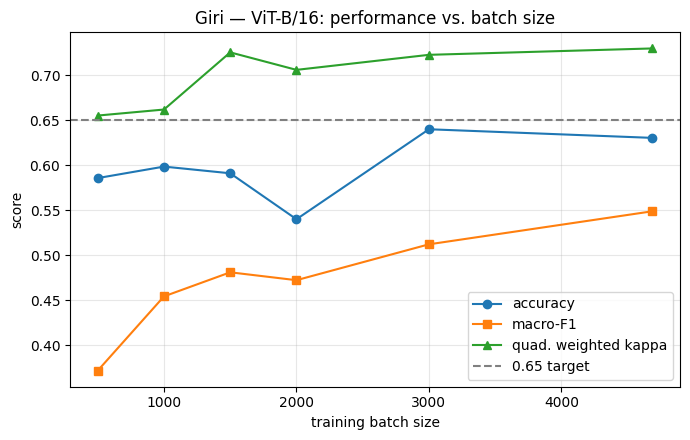

In [ ]:
# ============================================================
# COMPARISON ACROSS BATCH SIZES (ViT)
# ============================================================
import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(all_results)[
    ["batch","accuracy","macro_f1","weighted_f1","quadratic_weighted_kappa"]].sort_values("batch")
df.to_csv(os.path.join(DRIVE_OUT, MODEL_NAME, "summary.csv"), index=False)
print(df.to_string(index=False))

plt.figure(figsize=(7,4.5))
plt.plot(df.batch, df.accuracy, "o-", label="accuracy")
plt.plot(df.batch, df.macro_f1, "s-", label="macro-F1")
plt.plot(df.batch, df.quadratic_weighted_kappa, "^-", label="quad. weighted kappa")
plt.axhline(0.65, ls="--", color="grey", label="0.65 target")
plt.xlabel("training batch size"); plt.ylabel("score")
plt.title("Giri — ViT-B/16: performance vs. batch size")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT, MODEL_NAME, "summary.png"), dpi=120)
plt.show()


Google Drive is not mounted.
Mounting Google Drive now...
Mounted at /content/drive
Google Drive ready.

Results folder:
/content/drive/MyDrive/KOA/runs/vit

CONFUSION MATRICES FOUND
batch_500_confusion.csv
batch_1000_confusion.csv
batch_1500_confusion.csv
batch_2000_confusion.csv
batch_3000_confusion.csv
batch_4686_confusion.csv

Plotting confusion matrix for batch_500...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_500_confusion.png


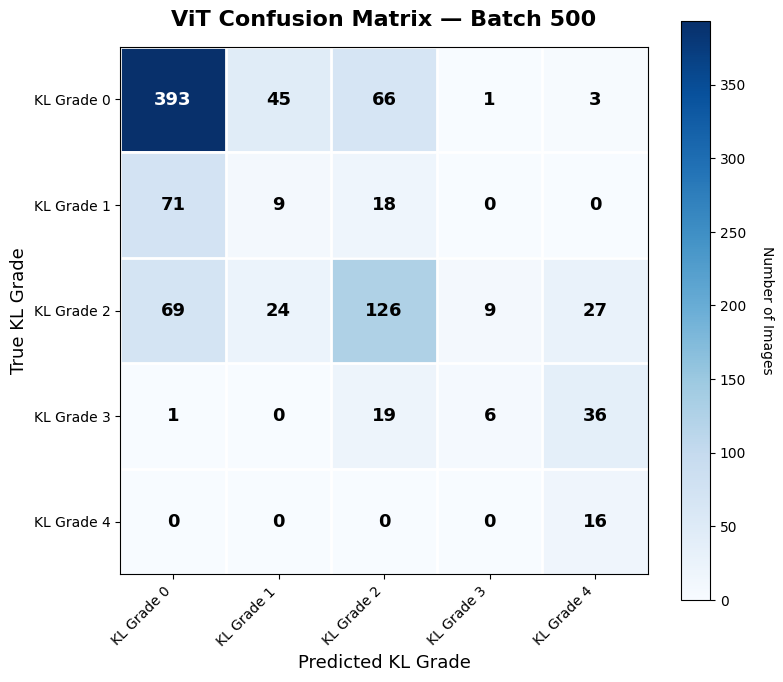


Plotting confusion matrix for batch_1000...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_1000_confusion.png


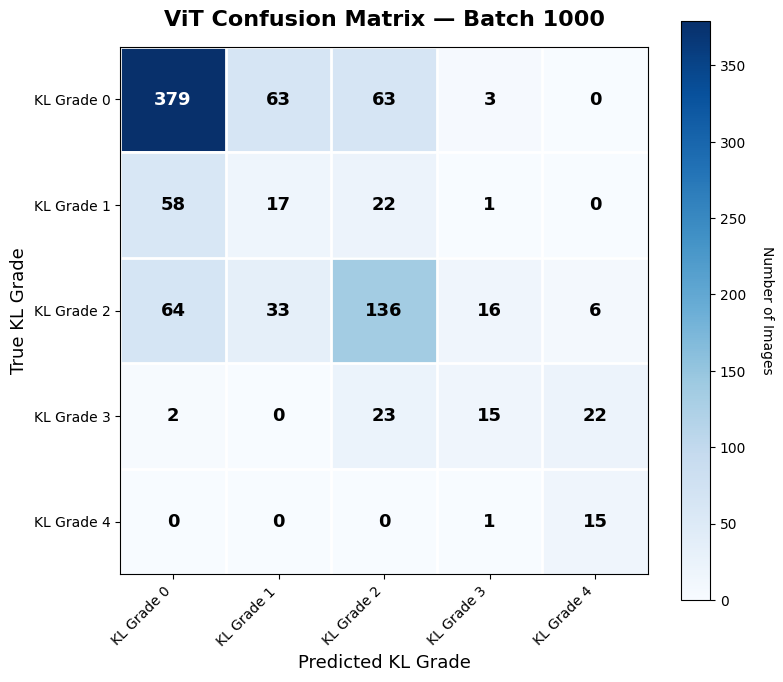


Plotting confusion matrix for batch_1500...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_1500_confusion.png


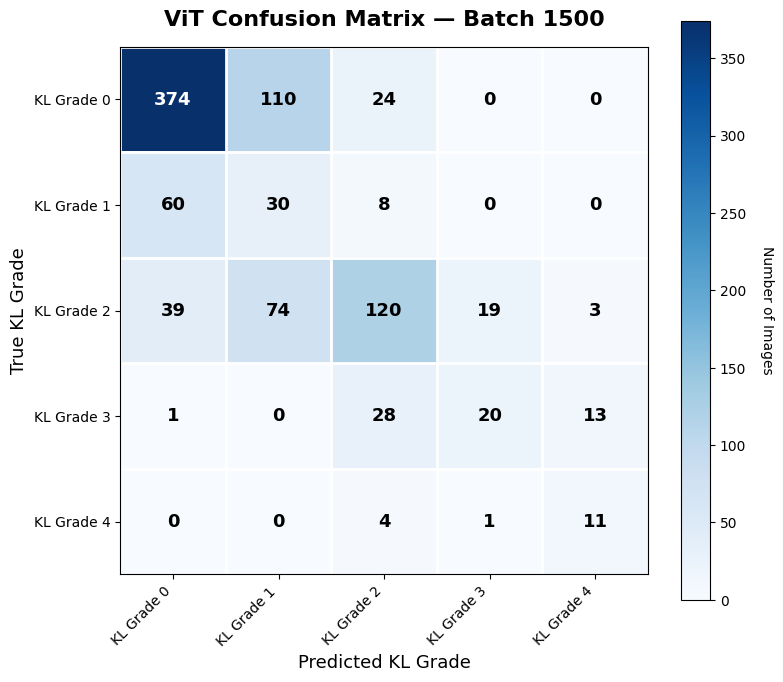


Plotting confusion matrix for batch_2000...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_2000_confusion.png


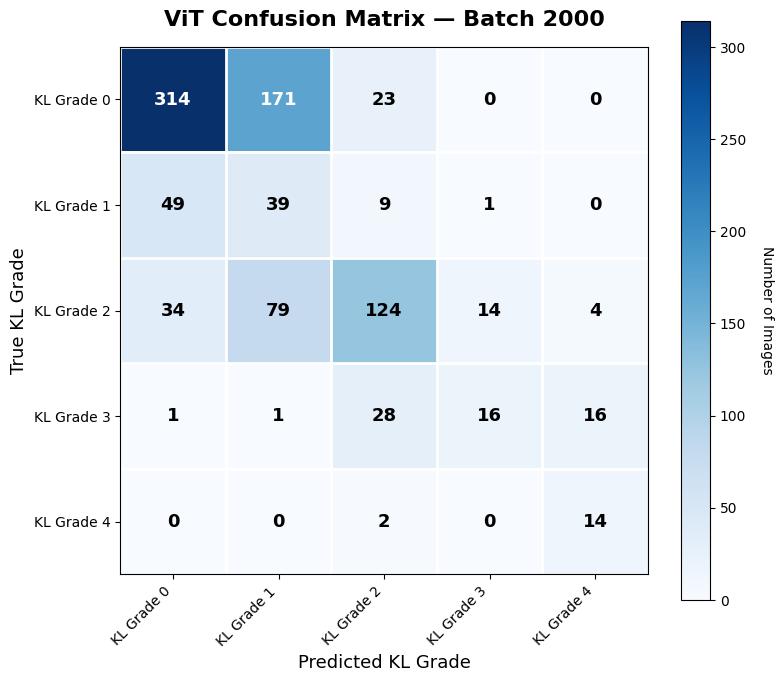


Plotting confusion matrix for batch_3000...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_3000_confusion.png


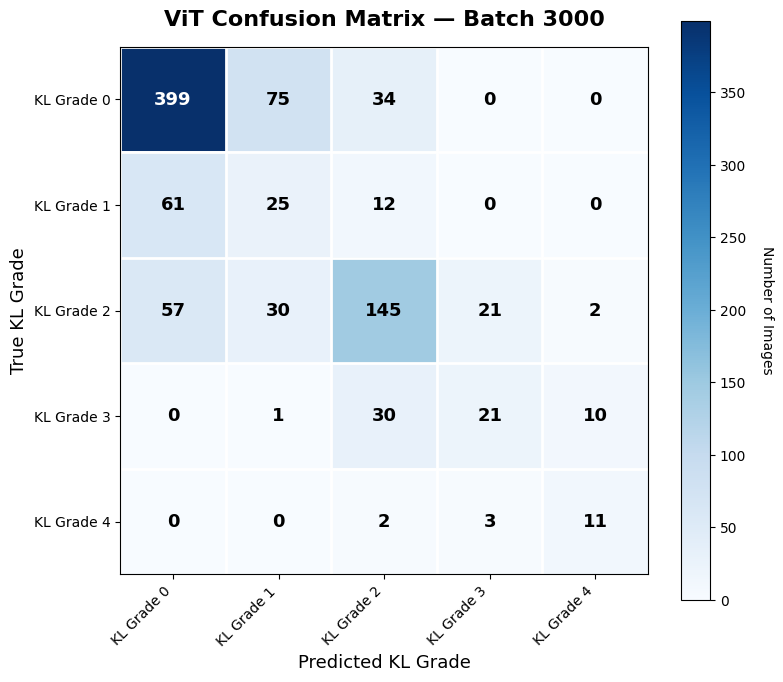


Plotting confusion matrix for batch_4686...
✅ Saved: /content/drive/MyDrive/KOA/runs/vit/batch_4686_confusion.png


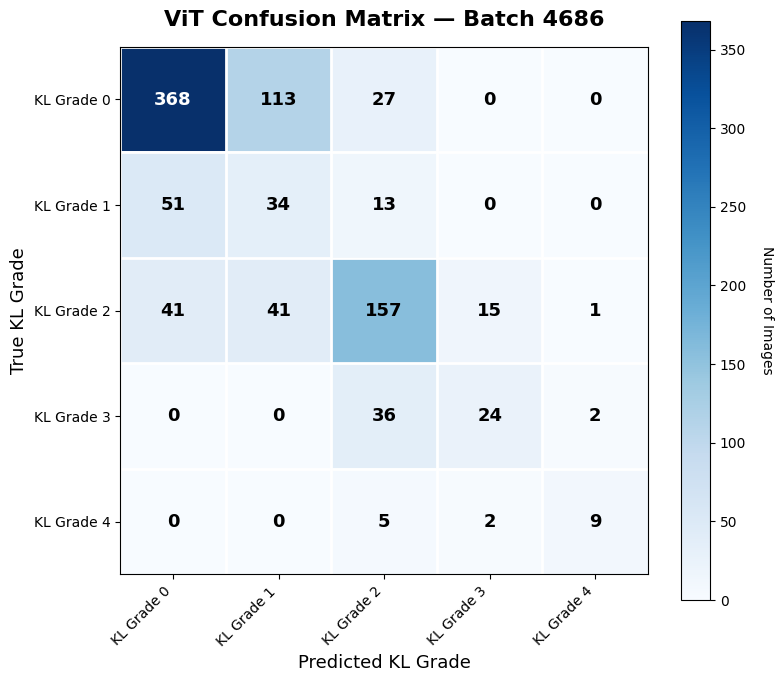


✅ ALL AVAILABLE CONFUSION MATRICES COMPLETED


In [ ]:
# ============================================================
# CONFUSION MATRICES FOR ALL ViT BATCHES
# Works from saved batch_*_confusion.csv files
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CHECK GOOGLE DRIVE
# ------------------------------------------------------------

DRIVE_ROOT = "/content/drive"

if not os.path.exists("/content/drive/MyDrive"):
    print("Google Drive is not mounted.")
    print("Mounting Google Drive now...")

    from google.colab import drive
    drive.mount("/content/drive")

print("Google Drive ready.")


# ------------------------------------------------------------
# 2. FIND KOA FOLDER
# ------------------------------------------------------------

MYDRIVE = "/content/drive/MyDrive"

possible_dirs = [
    os.path.join(MYDRIVE, "KOA", "runs", "vit"),
    os.path.join(MYDRIVE, "KOA", "runs", "ViT"),
    os.path.join(MYDRIVE, "all batches", "runs", "vit"),
]

outdir = None

for d in possible_dirs:
    if os.path.exists(d):
        outdir = d
        break

# If exact folder was not found, search MyDrive
if outdir is None:
    print("\nSearching Google Drive for confusion CSV files...")

    found = glob.glob(
        os.path.join(MYDRIVE, "**", "batch_*_confusion.csv"),
        recursive=True
    )

    if found:
        outdir = os.path.dirname(found[0])

print("\nResults folder:")
print(outdir)


# ------------------------------------------------------------
# 3. STOP IF NO CONFUSION FILES EXIST
# ------------------------------------------------------------

if outdir is None:
    print("\n❌ No confusion-matrix CSV files were found.")
    print("\nYour training/evaluation code must first create files such as:")
    print("batch_500_confusion.csv")
    print("batch_1000_confusion.csv")
    print("batch_1500_confusion.csv")
    print("batch_2000_confusion.csv")
    print("batch_3000_confusion.csv")
    print("batch_4686_confusion.csv")

else:

    # --------------------------------------------------------
    # 4. FIND ALL CONFUSION MATRICES
    # --------------------------------------------------------

    confusion_files = glob.glob(
        os.path.join(outdir, "batch_*_confusion.csv")
    )

    def get_batch_number(path):
        name = os.path.basename(path)
        try:
            return int(name.split("batch_")[1].split("_")[0])
        except:
            return 999999

    confusion_files = sorted(
        confusion_files,
        key=get_batch_number
    )

    print("\n============================================================")
    print("CONFUSION MATRICES FOUND")
    print("============================================================")

    for f in confusion_files:
        print(os.path.basename(f))

    if len(confusion_files) == 0:
        print("\n❌ No batch confusion CSV files found.")

    else:

        # ----------------------------------------------------
        # 5. NUMBER OF KL CLASSES
        # ----------------------------------------------------

        NUM_CLASSES = 5

        grades = [
            "KL Grade 0",
            "KL Grade 1",
            "KL Grade 2",
            "KL Grade 3",
            "KL Grade 4"
        ]

        # ----------------------------------------------------
        # 6. PLOT EACH BATCH
        # ----------------------------------------------------

        for f in confusion_files:

            batch = get_batch_number(f)

            print(
                f"\nPlotting confusion matrix for batch_{batch}..."
            )

            # Read CSV
            cm = np.loadtxt(
                f,
                delimiter=",",
                dtype=int
            )

            # Make sure it is 5 x 5
            if cm.size != NUM_CLASSES * NUM_CLASSES:
                print(
                    f"⚠️ Skipping batch_{batch}: "
                    f"CSV contains {cm.size} values instead of 25."
                )
                continue

            cm = cm.reshape(NUM_CLASSES, NUM_CLASSES)

            # ------------------------------------------------
            # CREATE FIGURE
            # ------------------------------------------------

            fig, ax = plt.subplots(
                figsize=(8, 7)
            )

            im = ax.imshow(
                cm,
                interpolation="nearest",
                cmap="Blues"
            )

            # Title
            ax.set_title(
                f"ViT Confusion Matrix — Batch {batch}",
                fontsize=16,
                fontweight="bold",
                pad=15
            )

            # Axis labels
            ax.set_xlabel(
                "Predicted KL Grade",
                fontsize=13
            )

            ax.set_ylabel(
                "True KL Grade",
                fontsize=13
            )

            # Ticks
            ax.set_xticks(range(NUM_CLASSES))
            ax.set_yticks(range(NUM_CLASSES))

            ax.set_xticklabels(
                grades,
                rotation=45,
                ha="right"
            )

            ax.set_yticklabels(grades)

            # ------------------------------------------------
            # WRITE VALUES INSIDE CELLS
            # ------------------------------------------------

            threshold = cm.max() / 2.0

            for i in range(NUM_CLASSES):
                for j in range(NUM_CLASSES):

                    value = cm[i, j]

                    ax.text(
                        j,
                        i,
                        str(value),
                        ha="center",
                        va="center",
                        fontsize=13,
                        fontweight="bold",
                        color="white"
                        if value > threshold
                        else "black"
                    )

            # Color bar
            cbar = fig.colorbar(im, ax=ax)

            cbar.set_label(
                "Number of Images",
                rotation=270,
                labelpad=20
            )

            # Grid
            ax.set_xticks(
                np.arange(NUM_CLASSES) - 0.5,
                minor=True
            )

            ax.set_yticks(
                np.arange(NUM_CLASSES) - 0.5,
                minor=True
            )

            ax.grid(
                which="minor",
                color="white",
                linestyle="-",
                linewidth=2
            )

            ax.tick_params(
                which="minor",
                bottom=False,
                left=False
            )

            plt.tight_layout()

            # ------------------------------------------------
            # SAVE PNG
            # ------------------------------------------------

            output_png = os.path.join(
                outdir,
                f"batch_{batch}_confusion.png"
            )

            fig.savefig(
                output_png,
                dpi=200,
                bbox_inches="tight"
            )

            print(
                f"✅ Saved: {output_png}"
            )

            plt.show()

            plt.close(fig)

        print("\n============================================================")
        print("✅ ALL AVAILABLE CONFUSION MATRICES COMPLETED")
        print("============================================================")

### Notes
- **Controlled version** — same loader, transforms, normalization, sampler,
  epochs, batch size, schedule and frozen test as the other three members.
  Only `build_model` differs.
- **No validation by design.** Fixed 30 epochs, final model tested.
- **Checkpoints off** because your Drive is ~90% full. Metrics/confusion/summary
  are tiny and still saved to `MyDrive/KOA/runs/vit/`.
- All six zips are present now, so nothing should be skipped.
